In [3]:
# Import Libraries and Configure Environment
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting style
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Ensure project root is on the path (if needed)
BASE_DIR = Path.cwd()          # or Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)

Base directory: c:\MCA_acadamics\f1_prediction
Data directory: c:\MCA_acadamics\f1_prediction\data


In [4]:
# Load datasets using pandas and existing preprocess helpers
from src.preprocess import load_data, merge_data, feature_engineering

# Load raw tables
results, races, drivers, circuits = load_data()
print("Results:", results.shape)
print("Races:", races.shape)
print("Drivers:", drivers.shape)
print("Circuits:", circuits.shape)

display(results.head())
display(races.head())

# Merge and basic cleaning
merged_df = merge_data()
print("Merged df shape:", merged_df.shape)
merged_df.head()

Results: (27282, 18)
Races: (1171, 18)
Drivers: (865, 9)
Circuits: (78, 9)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


Merged df shape: (27262, 51)


,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,nationality,url_y,circuitRef,name_y,location,country,lat,lng,alt,url
0,1,18,1,1,22,1.0,1,1,1,10.0,...,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,18,2,2,3,5.0,2,2,2,8.0,...,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,3,18,3,3,7,7.0,3,3,3,6.0,...,German,http://en.wikipedia.org/wiki/Nico_Rosberg,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
3,4,18,4,4,5,11.0,4,4,4,5.0,...,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
4,5,18,5,1,23,3.0,5,5,5,4.0,...,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


In [5]:
# Basic info and missing values
print("Merged dtypes:")
print(merged_df.dtypes.head(20))

print("\nMissing values per column (top 20):")
print(merged_df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", merged_df.duplicated().sum())

merged_df.describe(include="all").transpose().head(20)

Merged dtypes:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number_x               str
grid               float64
position               str
positionText           str
positionOrder        int64
points             float64
laps                 int64
time_x                 str
milliseconds           str
fastestLap             str
rank                   str
fastestLapTime         str
fastestLapSpeed        str
statusId             int64
year                 int64
round                int64
dtype: object

Missing values per column (top 20):
milliseconds       19240
time_x             19240
fastestLapSpeed    19010
fastestLapTime     18535
fastestLap         18535
rank               18277
position           10953
number_x               6
driverId               0
resultId               0
raceId                 0
laps                   0
points                 0
positionOrder          0
positionText           0
grid               

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
resultId,27262.0,NaN,NaN,NaN,13632.598562,7871.496908,1.0,6816.25,13631.5,20449.75,27287.0
raceId,27262.0,NaN,NaN,NaN,562.859842,320.883367,1.0,305.0,539.0,825.0,1170.0
driverId,27262.0,NaN,NaN,NaN,287.617123,289.628224,1.0,59.0,173.0,427.0,866.0
constructorId,27262.0,NaN,NaN,NaN,51.00088,62.524596,1.0,6.0,25.0,63.0,217.0
number_x,27256,129,4,1042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grid,27262.0,NaN,NaN,NaN,11.124349,7.180109,0.0,5.0,11.0,17.0,34.0
position,16309,33,3,1160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positionText,27262,39,R,8948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positionOrder,27262.0,NaN,NaN,NaN,12.75299,7.641755,1.0,6.0,12.0,18.0,39.0
points,27262.0,NaN,NaN,NaN,2.043579,4.438085,0.0,0.0,0.0,2.0,50.0


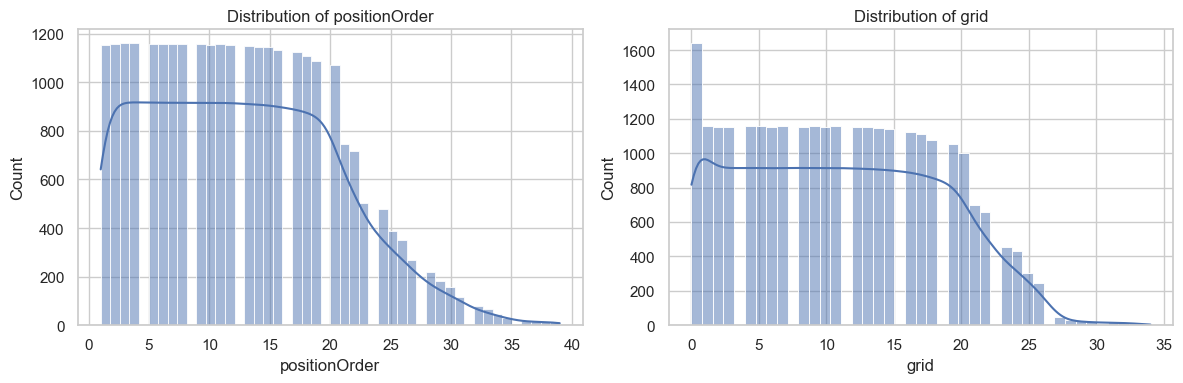

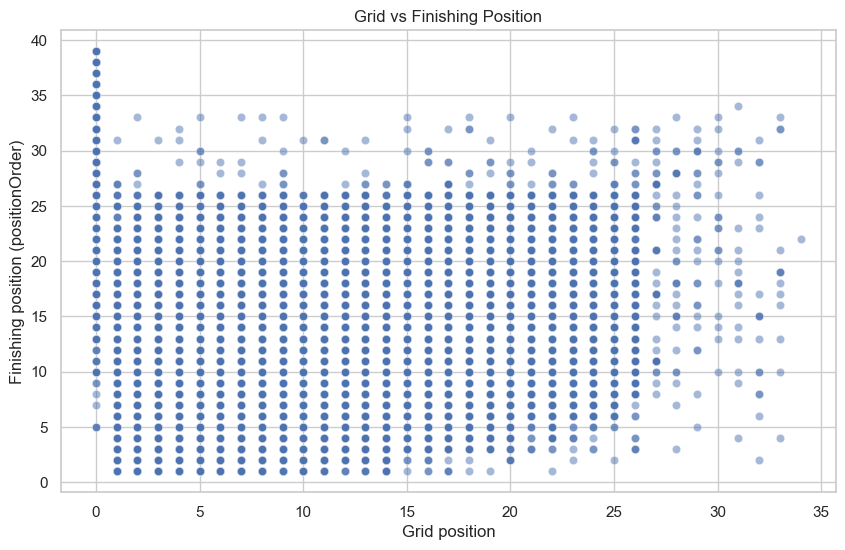

In [6]:
# Histograms for key numeric columns
numeric_cols = ["positionOrder", "grid"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 4))

if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.histplot(merged_df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Relationship between grid and finishing position
plt.figure()
sns.scatterplot(data=merged_df, x="grid", y="positionOrder", alpha=0.5)
plt.title("Grid vs Finishing Position")
plt.xlabel("Grid position")
plt.ylabel("Finishing position (positionOrder)")
plt.show()

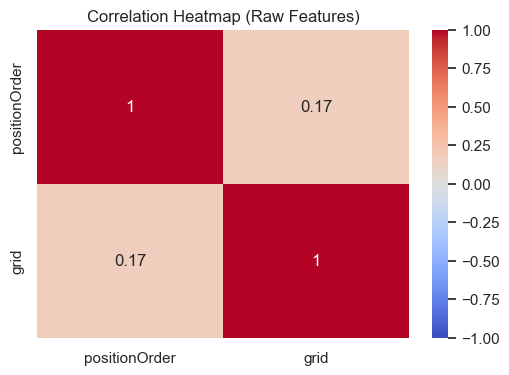

In [7]:
# Correlation heatmap for selected numeric features
corr_cols = ["positionOrder", "grid"]

corr = merged_df[corr_cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Raw Features)")
plt.show()

In [8]:
# Apply feature engineering
fe_df = feature_engineering(merged_df.copy())
print("Feature-engineered df shape:", fe_df.shape)

# Inspect new columns
new_cols = ["avg_pos_last5", "constructor_avg_pos", "target"]
fe_df[new_cols + ["positionOrder", "grid"]].head()

Feature-engineered df shape: (27262, 54)


,avg_pos_last5,constructor_avg_pos,target,positionOrder,grid
7572,12.75299,12.75299,0.050000,20,18.0
7579,20.00000,20.00000,0.142857,7,12.0
7598,13.50000,13.50000,0.166667,6,9.0
7616,11.00000,11.00000,0.250000,4,5.0
7641,9.25000,9.25000,0.111111,9,14.0


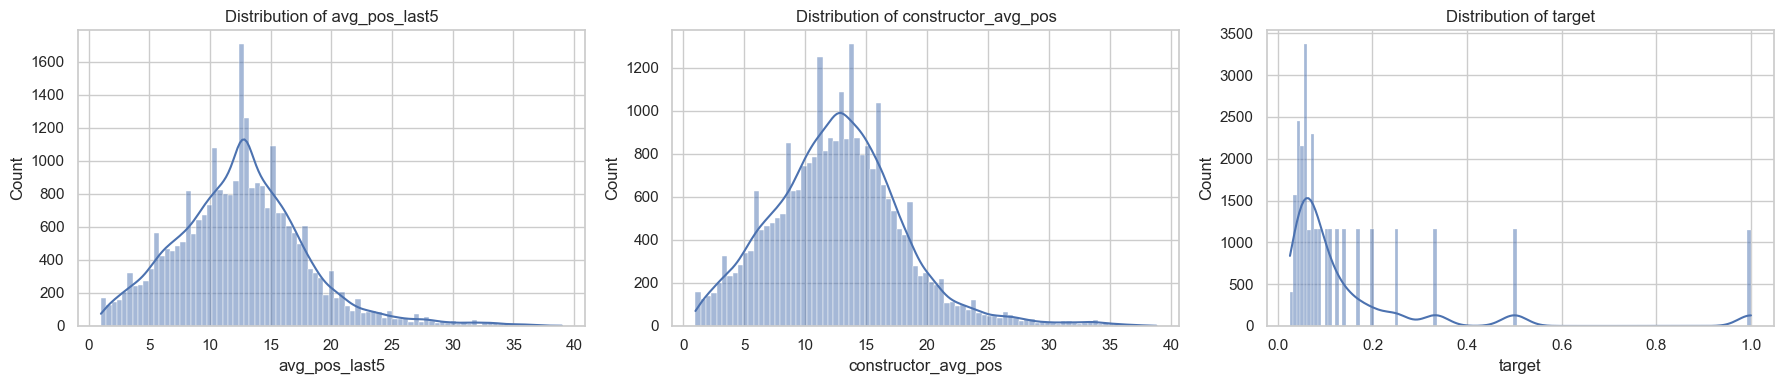

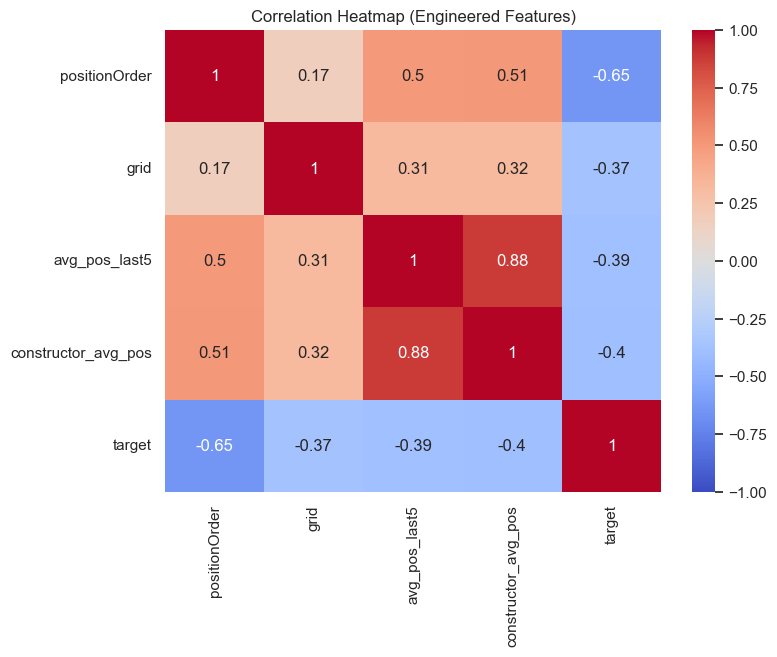

In [9]:
# Visualize engineered numeric features
eng_cols = ["avg_pos_last5", "constructor_avg_pos", "target"]

fig, axes = plt.subplots(1, len(eng_cols), figsize=(6 * len(eng_cols), 4))

for ax, col in zip(axes, eng_cols):
    sns.histplot(fe_df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Correlation heatmap including engineered features
corr_cols = ["positionOrder", "grid", "avg_pos_last5", "constructor_avg_pos", "target"]

corr = fe_df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Engineered Features)")
plt.show()

In [10]:
# Define features and target as in src.train
feature_cols = [
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "avg_pos_last5",
    "constructor_avg_pos",
]

y = fe_df["target"]
X = fe_df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((21809, 6), (5453, 6))

In [11]:
# Train RandomForestRegressor
rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

print("Trained RandomForestRegressor")

Trained RandomForestRegressor


## Compute Evaluation Metrics

We evaluate the model on the test set using MAE, MSE, RMSE, and $R^2$.

In [12]:
# Predictions and regression metrics
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation metrics (target = 1/positionOrder):")
print(f"MAE : {mae:.6f}")
print(f"MSE : {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.4f}")

Evaluation metrics (target = 1/positionOrder):
MAE : 0.091564
MSE : 0.028010
RMSE: 0.167363
R^2 : 0.3360


## Visualize Model Performance

We visualize predicted vs actual values and residuals to better understand model performance.

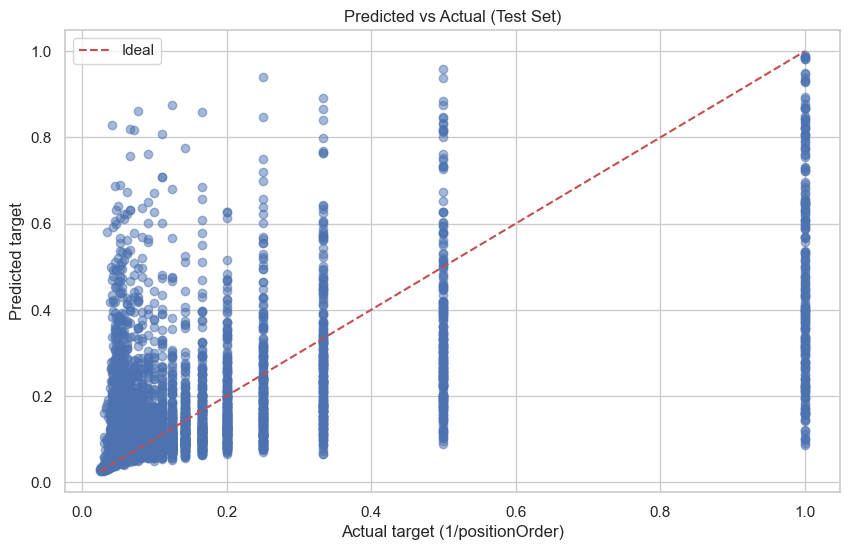

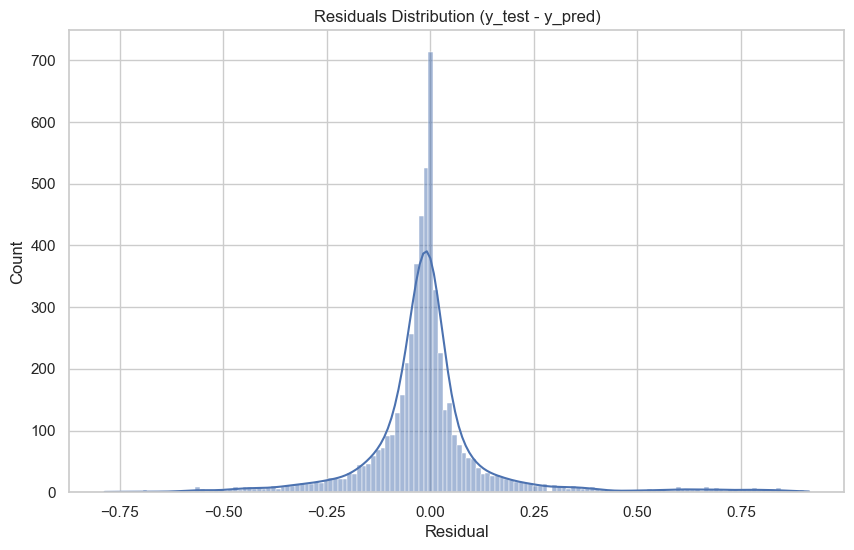

In [13]:
# Predicted vs actual scatter plot
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual target (1/positionOrder)")
plt.ylabel("Predicted target")
plt.title("Predicted vs Actual (Test Set)")
# Plot y=x reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Ideal")
plt.legend()
plt.show()

# Residuals histogram
residuals = y_test - y_pred
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (y_test - y_pred)")
plt.xlabel("Residual")
plt.show()